# Nav1.5 IFM-latching analysis

This notebook recreates the two-coordinate IFM plot for WT and the **IFM→QQQ fast-inactivation mutant**, separately for masked and vanilla predictions. QQQ replaces canonical I1485-F1486-M1487 with Q1485-Q1486-Q1487; it is not a selectivity-filter mutation. The contact definitions below are explicit and editable because the original figure labels (`IFM1` and `IFM2`) do not encode their residue pairs. Defaults test the central motif residue (F1486 in WT; Q1486 in QQQ) against N1659 and N1765.


In [1]:
from pathlib import Path
import csv, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
SUBSET = 'all_ok_3'  # Corrected 3 Å suffix; alternatives: 'all', 'all_ok', 'first_converged', or 'first_100_generated'.
CONDITION_COLORS = {'WT': '#4C78A8', 'QQQ': '#F58518'}

# Optional local directories containing the AF2 PDBs. Leave as None to use manifest paths.
# Example: PDB_ROOT_OVERRIDES[('QQQ','masked')] = Path('/path/to/qqq/masked')
PDB_ROOT_OVERRIDES = {key: None for key in [('WT','vanilla'),('WT','masked'),('QQQ','vanilla'),('QQQ','masked')]}

# Contact identities remain hypotheses, but the construct numbering below is
# sequence-verified against 6UZ3, 8VYJ, and 8VYK.
# Canonical 1485-1487/1659/1765 map to model 1169-1171/1343/1449.
# Distances are C-alpha to C-alpha. Change either residue tuple and rerun all cells.
IFM_CONTACT_DEFINITIONS_ARE_GUESSED = True
CONSTRUCT_NUMBERING_IS_SEQUENCE_VERIFIED = True
IFM_CONTACT_ALIASES = {
    'IFM1': {
        'display_alias': 'IFM/QQQ central residue–N1659 (model F/Q1170–N1343)',
        'WT': (('PHE', 1170), ('ASN', 1343)),
        'QQQ': (('GLN', 1170), ('ASN', 1343)),
        'WT_csv_column': 'CA_PHE1170_CA-ASN1343_CA',
        'QQQ_csv_column': 'CA_GLN1170_CA-ASN1343_CA',
        'interpretation': 'central inactivation-motif residue to DIV receptor-site N1659',
    },
    'IFM2': {
        'display_alias': 'IFM/QQQ central residue–N1765 (model F/Q1170–N1449)',
        'WT': (('PHE', 1170), ('ASN', 1449)),
        'QQQ': (('GLN', 1170), ('ASN', 1449)),
        'WT_csv_column': 'CA_PHE1170_CA-ASN1449_CA',
        'QQQ_csv_column': 'CA_GLN1170_CA-ASN1449_CA',
        'interpretation': 'central inactivation-motif residue to distal intracellular N1765',
    },
}
IFM_CONTACT_ALIASES


{'IFM1': {'display_alias': 'IFM/QQQ central residue–N1659',
  'WT': (('PHE', 1486), ('ASN', 1659)),
  'QQQ': (('GLN', 1486), ('ASN', 1659)),
  'WT_csv_column': 'CA_PHE1486_CA-ASN1659_CA',
  'QQQ_csv_column': 'CA_GLN1486_CA-ASN1659_CA',
  'interpretation': 'central inactivation-motif residue to DIV receptor-site N1659'},
 'IFM2': {'display_alias': 'IFM/QQQ central residue–N1765',
  'WT': (('PHE', 1486), ('ASN', 1765)),
  'QQQ': (('GLN', 1486), ('ASN', 1765)),
  'WT_csv_column': 'CA_PHE1486_CA-ASN1765_CA',
  'QQQ_csv_column': 'CA_GLN1486_CA-ASN1765_CA',
  'interpretation': 'central inactivation-motif residue to distal intracellular N1765'}}

## Dataset paths and subset selection


In [2]:
MANIFESTS = {
    ('WT','vanilla'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_wt_vanilla/all_models_manifest.csv',
    ('WT','masked'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_wt_masked_v2/all_models_manifest.csv',
    ('QQQ','vanilla'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_qqq_vanilla/all_models_manifest.csv',
    ('QQQ','masked'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_qqq_masked_v2/all_models_manifest.csv',
}

def select_manifest_rows(path, subset):
    df = pd.read_csv(path)
    if subset == 'all':
        return df[df['parse_ok'].fillna(False)].copy()
    if subset == 'all_ok':
        return df[df['all_ok'].fillna(False)].copy()
    if subset == 'all_ok_3':
        # Successive RMSD must pass for the candidate recycle itself and for
        # every later recycle. This avoids accepting a failed terminal recycle.
        selected=[]
        work=df[~df['is_base'].fillna(False)].copy()
        for _,trajectory in work.groupby(['seed','model_number'],sort=False):
            trajectory=trajectory.sort_values('recycle_number')
            passed=(pd.to_numeric(trajectory['rmsd_to_previous_available'],errors='coerce').le(3.0) & pd.to_numeric(trajectory['aligned_coverage_to_previous'],errors='coerce').ge(.9))
            starts=[i for i in range(len(trajectory)) if bool(passed.iloc[i:].all())]
            if starts: selected.append(trajectory.iloc[starts[0]:])
        return pd.concat(selected,ignore_index=True) if selected else work.iloc[0:0].copy()
    if subset == 'first_converged':
        return df[df['earliest_converged_selected'].fillna(False)].copy()
    if subset == 'first_100_generated':
        ok = df[df['all_ok'].fillna(False)].copy()
        trajectories = (ok[['seed','model_number']].drop_duplicates()
                        .sort_values(['seed','model_number']).head(100))
        return ok.merge(trajectories, on=['seed','model_number'], how='inner')
    raise ValueError(f'Unknown SUBSET: {subset}')

path_audit = pd.DataFrame([{'condition': c, 'protocol': p, 'manifest': str(path), 'exists': path.is_file()} for (c,p),path in MANIFESTS.items()])
display(path_audit)
assert path_audit['exists'].all(), 'A required RMSD manifest is missing.'

# Audit all current Nav1.5 distance CSVs. These tables can be used directly only
# if the requested IFM-contact columns are present.
PRECOMPUTED_DISTANCE_CSVS = [
    repo_root/'nav15/dataDistances/25-12-02_Nav15_wt_vanillaAF2_distances.csv',
    repo_root/'nav15/dataDistances/26-07-25_Nav15_wt_maskedv2_AF2_distances_all.csv',
    repo_root/'nav15/dataDistances/26-07-25_Nav15_wt_maskedv2_noIFM_AF2_distances_all.csv',
    repo_root/'nav15/dataDistances/26-02-01_Nav15_qqq_vanilla_distances_all.csv',
    repo_root/'nav15/dataDistances/26-07-24_Nav15_qqq_maskedAF2_distances_all.csv',
    repo_root/'nav15/dataDistances/26-07-25_Nav15_qqq_maskedAF2v2_distances_all.csv',
]
required_tokens = ('1169','1170','1171','1343','1449')
precomputed_audit = []
for path in PRECOMPUTED_DISTANCE_CSVS:
    header = pd.read_csv(path, nrows=0).columns.tolist()
    matches = [column for column in header if any(token in column.upper() for token in required_tokens)]
    precomputed_audit.append({'csv': path.name, 'columns': len(header), 'IFM_related_columns': matches})
display(pd.DataFrame(precomputed_audit))


,condition,protocol,manifest,exists
0,WT,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
1,WT,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
2,QQQ,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
3,QQQ,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True


,csv,columns,IFM_related_columns
0,25-12-02_Nav15_wt_vanillaAF2_distances.csv,653,[]
1,26-07-25_Nav15_wt_maskedv2_AF2_distances_all.csv,1013,[]
2,26-07-25_Nav15_wt_maskedv2_noIFM_AF2_distances...,1013,[]
3,26-02-01_Nav15_qqq_vanilla_distances_all.csv,1013,[]
4,26-07-24_Nav15_qqq_maskedAF2_distances_all.csv,1013,[]
5,26-07-25_Nav15_qqq_maskedAF2v2_distances_all.csv,1013,[]


## Calculate IFM coordinates directly from each AF2 PDB


In [3]:
def ca_atoms(pdb_path, chain='A'):
    atoms = {}
    with open(pdb_path, errors='ignore') as handle:
        for line in handle:
            if not line.startswith('ATOM') or line[21].strip() != chain or line[12:16].strip() != 'CA':
                continue
            key = (line[17:20].strip(), int(line[22:26]))
            atoms[key] = np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return atoms

def calculate_contacts(pdb_path, condition):
    atoms = ca_atoms(pdb_path)
    values = {}
    for label, definition in IFM_CONTACT_ALIASES.items():
        a, b = definition[condition]
        values[label] = np.linalg.norm(atoms[a] - atoms[b]) if a in atoms and b in atoms else np.nan
    return values

def resolve_pdb_path(manifest_path, condition, protocol):
    original = Path(manifest_path)
    if original.is_file():
        return original
    override = PDB_ROOT_OVERRIDES[(condition, protocol)]
    return Path(override) / original.name if override is not None else original

rows = []
for (condition, protocol), manifest in MANIFESTS.items():
    selected = select_manifest_rows(manifest, SUBSET)
    for record in selected.itertuples(index=False):
        pdb_path = resolve_pdb_path(record.pdb_file, condition, protocol)
        values = calculate_contacts(pdb_path, condition) if pdb_path.is_file() else {'IFM1': np.nan, 'IFM2': np.nan}
        rows.append({'Condition': condition, 'Protocol': protocol, 'pdb_file': str(pdb_path), **values})
ifm_df = pd.DataFrame(rows)
availability = (ifm_df.groupby(['Condition','Protocol']).agg(models=('pdb_file','size'), IFM1=('IFM1','count'), IFM2=('IFM2','count')).reset_index())
display(availability)
DATA_READY = ifm_df[['IFM1','IFM2']].notna().all(axis=1).any()
if not DATA_READY:
    print('The sequence-verified IFM1 column (F/Q1170–N1343) is present in the new CSVs, but IFM2 (F/Q1170–N1449) is absent.')
    print('Set PDB_ROOT_OVERRIDES to the AF2 PDB directories, or calculate the N1449 column, to restore the 2D joint distributions.')


,Condition,Protocol,models,IFM1,IFM2
0,QQQ,masked,5000,0,0
1,QQQ,vanilla,5000,0,0
2,WT,masked,4999,0,0
3,WT,vanilla,5000,0,0


IFM distances are unavailable: existing distance CSVs stop at residue 1459, and manifest PDB paths are not mounted.
Set PDB_ROOT_OVERRIDES above to local AF2 PDB directories, then rerun.


## WT versus QQQ joint distributions


In [4]:
def plot_ifm_joint(data, protocol):
    plot_df = data[data['Protocol'].eq(protocol)].dropna(subset=['IFM1','IFM2'])
    g = sns.JointGrid(data=plot_df, x='IFM1', y='IFM2', height=7, ratio=4, space=0)
    for condition in ('WT','QQQ'):
        part = plot_df[plot_df['Condition'].eq(condition)]
        color = CONDITION_COLORS[condition]
        g.ax_joint.scatter(part['IFM1'], part['IFM2'], s=18, alpha=.72, color=color, edgecolor='#333333', linewidth=.25)
        sns.histplot(part['IFM1'], stat='density', kde=True, color=color, alpha=.35, ax=g.ax_marg_x)
        sns.histplot(y=part['IFM2'], stat='density', kde=True, color=color, alpha=.35, ax=g.ax_marg_y)
    experimental_markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']
    experimental_colors = ['#D55E00', '#0072B2', '#009E73', '#CC79A7']
    for i, (pdb_id, values) in enumerate(globals().get('EXPERIMENTAL_IFM_DISTANCES', {}).items()):
        g.ax_joint.scatter(values['IFM1'], values['IFM2'], marker=experimental_markers[i % len(experimental_markers)], s=95, color=experimental_colors[i % len(experimental_colors)], edgecolor='white', linewidth=.7, zorder=10)
        g.ax_joint.annotate(pdb_id, (values['IFM1'], values['IFM2']), xytext=(5,5), textcoords='offset points', fontsize=8)
    g.ax_joint.set_xlabel(f"IFM1 | {IFM_CONTACT_ALIASES['IFM1']['display_alias']} (Å)")
    g.ax_joint.set_ylabel(f"IFM2 | {IFM_CONTACT_ALIASES['IFM2']['display_alias']} (Å)")
    qualifier = 'hypothesis: guessed contact definitions' if IFM_CONTACT_DEFINITIONS_ARE_GUESSED else 'confirmed contact definitions'
    g.ax_joint.set_title(f'Nav1.5 | WT vs QQQ | {protocol} | IFM latching | {SUBSET}\n{qualifier}', pad=12)
    handles = [Line2D([0],[0], marker='o', linestyle='', label=c, markerfacecolor=CONDITION_COLORS[c], markeredgecolor='#333333') for c in ('WT','QQQ')]
    g.ax_joint.legend(handles=handles, title='Condition')
    sns.despine(fig=g.figure)
    plt.show()



## Experimental audit and explicit distances


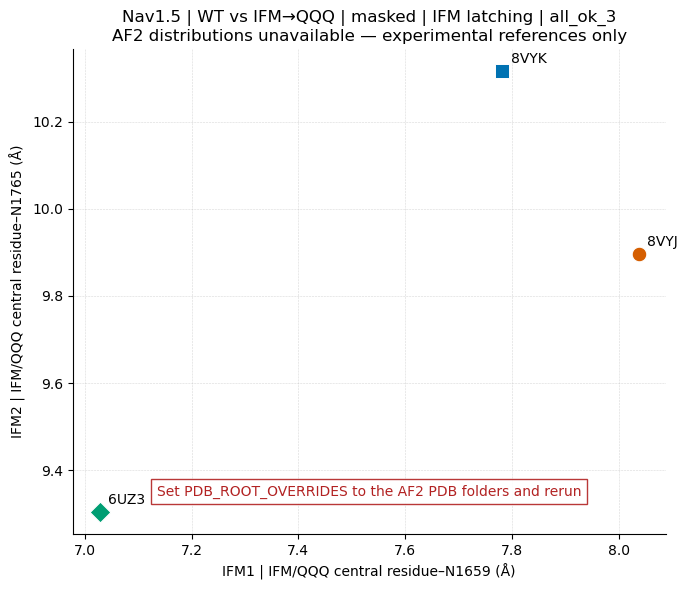

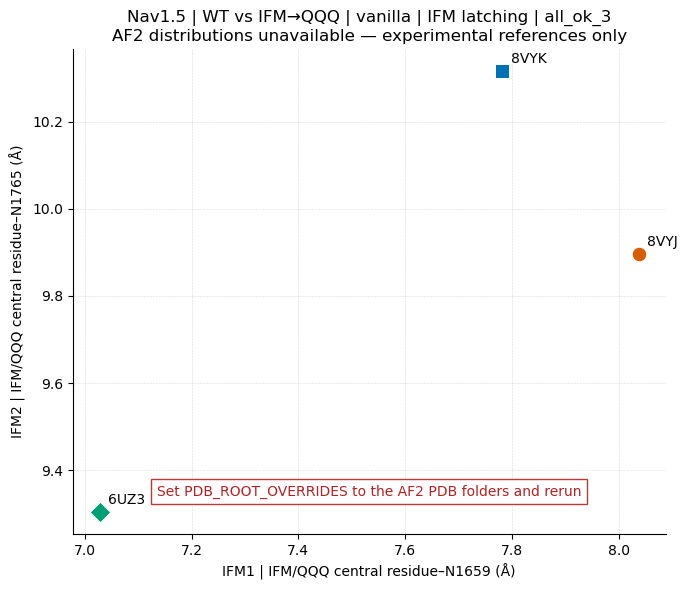

In [5]:
# 8VYJ/8VYK use canonical numbering. 6UZ3 is shifted +2 around this region.
EXPERIMENTAL_RESIDUE_MAP = {
    '8VYJ': {'IFM1': (('PHE',1486),('ASN',1659)), 'IFM2': (('PHE',1486),('ASN',1765))},
    '8VYK': {'IFM1': (('PHE',1486),('ASN',1659)), 'IFM2': (('PHE',1486),('ASN',1765))},
    '6UZ3': {'IFM1': (('PHE',1488),('ASN',1661)), 'IFM2': (('PHE',1488),('ASN',1767))},
}

def explicit_experimental_distances():
    result = {}
    for pdb_id, mapping in EXPERIMENTAL_RESIDUE_MAP.items():
        atoms = ca_atoms(repo_root/f'nav15/experimental/{pdb_id}.pdb')
        result[pdb_id] = {label: round(float(np.linalg.norm(atoms[a]-atoms[b])), 3) for label,(a,b) in mapping.items()}
    return result

# Explicit editable values (Å), calculated from the residue map above.
EXPERIMENTAL_IFM_DISTANCES = {
    '8VYJ': {'IFM1': 8.037, 'IFM2': 9.896},
    '8VYK': {'IFM1': 7.782, 'IFM2': 10.316},
    '6UZ3': {'IFM1': 7.028, 'IFM2': 9.304},
}
recalculated = explicit_experimental_distances()
for pdb_id, expected in EXPERIMENTAL_IFM_DISTANCES.items():
    for alias, expected_value in expected.items():
        assert np.isclose(recalculated[pdb_id][alias], expected_value, atol=0.001), (pdb_id, alias, recalculated[pdb_id][alias], expected_value)
EXPERIMENTAL_IFM_DISTANCES

# Overlay these reference points on both protocol plots if desired.
def plot_missing_af2_panel(protocol):
    fig, ax = plt.subplots(figsize=(7, 6))
    experimental_markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']
    experimental_colors = ['#D55E00', '#0072B2', '#009E73', '#CC79A7']
    for i, (pdb_id, values) in enumerate(EXPERIMENTAL_IFM_DISTANCES.items()):
        ax.scatter(values['IFM1'], values['IFM2'], marker=experimental_markers[i % len(experimental_markers)], s=110, color=experimental_colors[i % len(experimental_colors)], edgecolor='white', linewidth=.7)
        ax.annotate(pdb_id, (values['IFM1'], values['IFM2']), xytext=(6,6), textcoords='offset points')
    ax.set_xlabel(f"IFM1 | {IFM_CONTACT_ALIASES['IFM1']['display_alias']} (Å)")
    ax.set_ylabel(f"IFM2 | {IFM_CONTACT_ALIASES['IFM2']['display_alias']} (Å)")
    ax.set_title(f'Nav1.5 | WT vs IFM→QQQ | {protocol} | IFM latching | {SUBSET}\nAF2 distributions unavailable — experimental references only')
    ax.text(.5, .08, 'Set PDB_ROOT_OVERRIDES to the AF2 PDB folders and rerun', transform=ax.transAxes, ha='center', color='#B22222', bbox={'facecolor':'white','edgecolor':'#B22222','alpha':.9})
    ax.grid(linestyle='--', linewidth=.4, alpha=.5)
    sns.despine(ax=ax); fig.tight_layout(); plt.show()

for protocol in ('masked','vanilla'):
    if DATA_READY:
        plot_ifm_joint(ifm_df, protocol)
    else:
        plot_missing_af2_panel(protocol)


## Alternative receptor contacts to test
This audit ranks nonlocal Cα neighbors of canonical F1486 in 8VYJ. AF2 constructs use F1170 (or Q1170 for QQQ). Copy a receptor tuple into both condition entries only after mapping its canonical residue number to the construct sequence.


In [6]:
reference_atoms = ca_atoms(repo_root/'nav15/experimental/8VYJ.pdb')
ifm_key = ('PHE', 1486)
candidate_rows = []
for (resname, resid), xyz in reference_atoms.items():
    if abs(resid - 1486) <= 15:
        continue
    candidate_rows.append({'candidate_tuple': (resname, resid), 'CA_distance_to_F1486_A': float(np.linalg.norm(reference_atoms[ifm_key]-xyz))})
CONTACT_CANDIDATES = pd.DataFrame(candidate_rows).sort_values('CA_distance_to_F1486_A').head(30).reset_index(drop=True)
display(CONTACT_CANDIDATES)


,candidate_tuple,CA_distance_to_F1486_A
0,"(VAL, 1323)",5.929959
1,"(ALA, 1656)",5.932060
2,"(VAL, 1322)",6.141618
3,"(ALA, 1326)",7.751818
4,"(ASN, 1659)",8.037214
5,"(ALA, 1769)",8.300080
6,"(PRO, 1655)",8.759599
7,"(LEU, 1657)",8.799131
8,"(ILE, 1660)",8.971834
9,"(MET, 1320)",9.231052


### Interpretation guardrail
A separated cluster can support sampling of different IFM-contact geometries, but these two distances alone do not establish open-pore gating or causal electromechanical coupling. Check the intracellular gate and pore-radius coordinates alongside IFM1/IFM2 before assigning an open state. The 7FBS QQQ structure does not contain resolved canonical IFM coordinates and is therefore not assigned fabricated experimental values.
